In [172]:
import pandas as pd

df = pd.read_csv('./../data/housing.csv')

df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [173]:
from sklearn.model_selection import train_test_split

TARGET_COLUMN = "median_house_value"

X_raw = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42
)

In [174]:

# To findout number of Col and Row
print("(row , column) = ",df.shape , "\n\n")

# To findout types of coloumns
print("columns type : \n" , df.dtypes , "\n\n")


# Number of null items
print("column with null : \n" , df.isnull().sum())

(row , column) =  (20640, 10) 


columns type : 
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object 


column with null : 
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [175]:
numeric_df = df.select_dtypes(include="number")

scale_info = numeric_df.agg(["min" , "max"]).T

scale_info["range"] = scale_info["max"] - scale_info["min"]

scale_info

,min,max,range
longitude,-124.3500,-114.3100,10.0400
latitude,32.5400,41.9500,9.4100
housing_median_age,1.0000,52.0000,51.0000
total_rooms,2.0000,39320.0000,39318.0000
total_bedrooms,1.0000,6445.0000,6444.0000
population,3.0000,35682.0000,35679.0000
households,1.0000,6082.0000,6081.0000
median_income,0.4999,15.0001,14.5002
median_house_value,14999.0000,500001.0000,485002.0000


In [176]:
missing_bedrooms = df[df["total_bedrooms"].isnull()]
filled_bedrooms = df[df["total_bedrooms"].notnull()]

# Findout if total_bedrooms's missing values is not some important data because of we want to remove or add median value to it

# print("missing_bedroom(median) : ", missing_bedrooms['median_house_value'].median())
# print("missing_bedroom(mean) : ", missing_bedrooms['median_house_value'].mean())
# print("filled_bedrooms(median) : ", filled_bedrooms['median_house_value'].median())
# print("filled_bedrooms(mean) : ", filled_bedrooms['median_house_value'].mean())
# print("missing_bedroom(median) : ", missing_bedrooms['median_income'].median())
# print("missing_bedroom(mean) : ", missing_bedrooms['median_income'].mean())
# print("filled_bedrooms(median) : ", filled_bedrooms['median_income'].median())
# print("filled_bedrooms(mean) : ", filled_bedrooms['median_income'].mean())


print("filled_bedrooms(median) : ", filled_bedrooms['total_bedrooms'].median())
print("filled_bedrooms(mean) : ", filled_bedrooms['total_bedrooms'].mean())

# Calculate the median only from training data
bedrooms_median = X_train_raw["total_bedrooms"].median()

# Fill missing values in training data
X_train_raw["total_bedrooms"] = (
    X_train_raw["total_bedrooms"].fillna(bedrooms_median)
)

# Fill missing values in test data using the training median
X_test_raw["total_bedrooms"] = (
    X_test_raw["total_bedrooms"].fillna(bedrooms_median)
)

# Temporary compatibility with the current downstream cells
df["total_bedrooms"] = df["total_bedrooms"].fillna(bedrooms_median)

# Check the result
print("Train missing values:", X_train_raw["total_bedrooms"].isna().sum())
print("Test missing values:", X_test_raw["total_bedrooms"].isna().sum())
print("DataFrame missing values:", df["total_bedrooms"].isna().sum())
print("Training median:", bedrooms_median)
print(X_train_raw["total_bedrooms"].isna().sum())
print(X_test_raw["total_bedrooms"].isna().sum())
print(bedrooms_median)


filled_bedrooms(median) :  435.0
filled_bedrooms(mean) :  537.8705525375618
Train missing values: 0
Test missing values: 0
DataFrame missing values: 0
Training median: 437.0
0
0
437.0


In [177]:
Q1 = df['total_rooms'].quantile(0.25)
Q3 = df['total_rooms'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = df[
  (df["total_rooms"] < lower) |
  (df["total_rooms"] > upper)
]

# Length of outlier
len(outlier)

1287

In [178]:
numeric_df = df.select_dtypes(include="number")

suspecious_values = []

for column in numeric_df.columns:
  Q1 = numeric_df[column].quantile(0.25)
  Q3 = numeric_df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR
  min_value = numeric_df[column].min()
  max_value = numeric_df[column].max()
  if min_value < lower :
    suspecious_values.append((column , "min" , min_value))
  if max_value > upper :
    suspecious_values.append((column , "max" , max_value))

suspecious_values

[('total_rooms', 'max', np.float64(39320.0)),
 ('total_bedrooms', 'max', np.float64(6445.0)),
 ('population', 'max', np.float64(35682.0)),
 ('households', 'max', np.float64(6082.0)),
 ('median_income', 'max', np.float64(15.0001)),
 ('median_house_value', 'max', np.float64(500001.0))]

In [179]:
for column in numeric_df.columns:
  min_value = numeric_df[column].min()
  max_value = numeric_df[column].max()

  min_count = (numeric_df[column] == min_value).sum()
  max_count = (numeric_df[column] == max_value).sum()

  min_ratio = (numeric_df[column] == min_value).mean()
  max_ratio = (numeric_df[column] == max_value).mean()
  print(
        column,
        "min:", min_value,
        "min_count:", min_count,
        "min_ratio:", min_ratio,
        "|",
        "max:", max_value,
        "max_count:", max_count,
        "max_ratio:", max_ratio
    )

longitude min: -124.35 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: -114.31 max_count: 1 max_ratio: 4.8449612403100775e-05
latitude min: 32.54 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: 41.95 max_count: 2 max_ratio: 9.689922480620155e-05
housing_median_age min: 1.0 min_count: 4 min_ratio: 0.0001937984496124031 | max: 52.0 max_count: 1273 max_ratio: 0.06167635658914729
total_rooms min: 2.0 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: 39320.0 max_count: 1 max_ratio: 4.8449612403100775e-05
total_bedrooms min: 1.0 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: 6445.0 max_count: 1 max_ratio: 4.8449612403100775e-05
population min: 3.0 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: 35682.0 max_count: 1 max_ratio: 4.8449612403100775e-05
households min: 1.0 min_count: 1 min_ratio: 4.8449612403100775e-05 | max: 6082.0 max_count: 1 max_ratio: 4.8449612403100775e-05
median_income min: 0.4999 min_count: 12 min_ratio: 0.0005813953488372093 | max: 15.0001 ma

In [180]:
print("housing_median_age : " , df["housing_median_age"].value_counts().sort_index().tail(10) , "\n")

print("median_house_value : " , df["median_house_value"].value_counts().sort_index().tail(10) , "\n")

housing_median_age :  housing_median_age
43.0     353
44.0     356
45.0     294
46.0     245
47.0     198
48.0     177
49.0     134
50.0     136
51.0      48
52.0    1273
Name: count, dtype: int64 

median_house_value :  median_house_value
497400.0      1
497600.0      1
498400.0      1
498600.0      1
498700.0      1
498800.0      1
499000.0      1
499100.0      1
500000.0     27
500001.0    965
Name: count, dtype: int64 



housing_median_age appears to be capped at 52.
The value 52 occurs 1273 times, while 51 occurs only 48 times.

<Axes: >

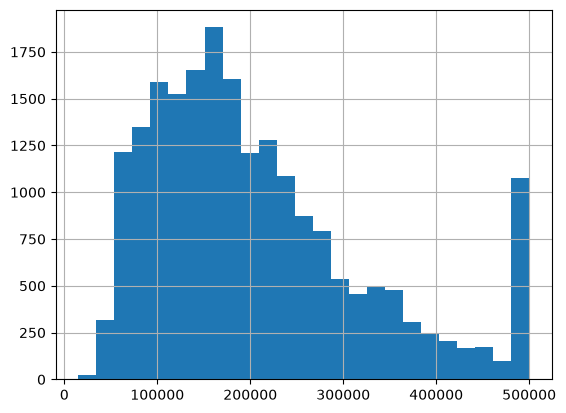

In [181]:
df["median_house_value"].hist(bins=25)

In [182]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [183]:
ocean_categories = {}

for category in df["ocean_proximity"].unique():
  ocean_categories[category] = df[df["ocean_proximity"] == category]

for ocean_cat_item in ocean_categories:
  print(
    ocean_cat_item,
    "\n median:",ocean_categories[ocean_cat_item]["median_house_value"].median(),
    "\n mean:" , ocean_categories[ocean_cat_item]["median_house_value"].mean(),
    "\n")

NEAR BAY 
 median: 233800.0 
 mean: 259212.31179039303 

<1H OCEAN 
 median: 214850.0 
 mean: 240084.28546409807 

INLAND 
 median: 108500.0 
 mean: 124805.39200122119 

NEAR OCEAN 
 median: 229450.0 
 mean: 249433.97742663656 

ISLAND 
 median: 414700.0 
 mean: 380440.0 



In [184]:
numeric_df.corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

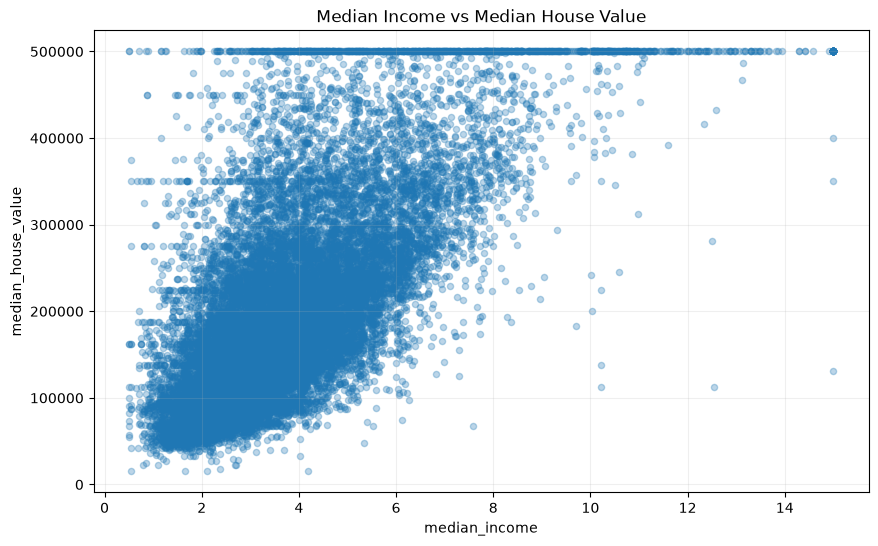

In [185]:
import matplotlib.pyplot as plt

mean_income = df["median_income"].mean()

plt.figure(figsize=(10,6))

plt.scatter(
    df["median_income"],
    df["median_house_value"],
    alpha=0.3,
    s=20
)

plt.title("Median Income vs Median House Value")
plt.xlabel("median_income")
plt.ylabel("median_house_value")


plt.grid(True ,alpha=0.2)

plt.show()

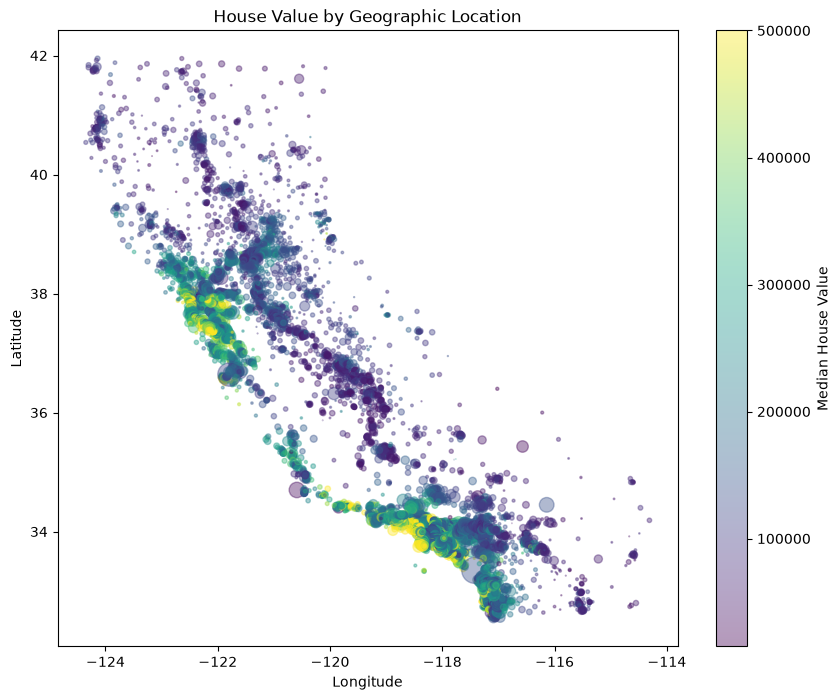

In [186]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
  df['longitude'],
  df['latitude'],
  c=df['median_house_value'],
  alpha=0.4,
  s=df["population"] / 100
)

plt.colorbar(scatter , label="Median House Value")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Value by Geographic Location")

plt.show()

In [187]:
X_train_encoded = pd.get_dummies(
    X_train_raw,
    columns=["ocean_proximity"],
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test_raw,
    columns=["ocean_proximity"],
    dtype=int
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

X_train_encoded["rooms_per_household"] = (
    X_train_encoded["total_rooms"] /
    X_train_encoded["households"]
)

X_test_encoded["rooms_per_household"] = (
    X_test_encoded["total_rooms"] /
    X_test_encoded["households"]
)

In [188]:
#Implement Random Forest section
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np





rf_model = RandomForestRegressor(
  random_state=42,
  max_depth=20,
  n_jobs=-1
)

rf_model.fit(X_train_encoded,y_train)

y_rf_predict = rf_model.predict(X_test_encoded)

MAE = mean_absolute_error(y_test , y_rf_predict )
MSE = mean_squared_error(y_test , y_rf_predict )
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_rf_predict)
residual = y_test - y_rf_predict

print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)
print("r2 : " , r2)
print("residual : " , residual)

y_train_predict = rf_model.predict(X_train_encoded)

train_r2 = r2_score(y_train, y_train_predict)

print("Train R²:", train_r2)
print("Test R²:", r2)

print(X_train_encoded.shape)
print("rooms_per_household" in X_train_encoded.columns)

MAE :  31579.534904636508
MSE :  2377399851.3592353
RMSE :  48758.58746271507
r2 :  0.8185757354508766
residual :  20046    -3059.396856
3024    -22299.352966
15663    27532.570000
20484   -24063.951122
9814      9252.641944
             ...     
15362    47698.385199
16623    19473.450022
18086     1995.020000
2144      3006.029404
3665    -21848.806183
Name: median_house_value, Length: 4128, dtype: float64
Train R²: 0.9730016946947102
Test R²: 0.8185757354508766
(16512, 14)
True


In [189]:
#Impelement Cross-Validation
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf_cv_model = RandomForestRegressor(
  random_state=42
)

score = cross_val_score(
  rf_cv_model,
  X_train_encoded,
  y_train,
  cv=5,
  scoring="r2"
)

print(score)
print("Mean CV R2 : ",score.mean())

[0.81987059 0.80975782 0.81614361 0.81614011 0.81607521]
Mean CV R2 :  0.8155974652589615


In [190]:
from sklearn.preprocessing import PolynomialFeatures

# geo_features = encoded[["latitude" , "longitude"]]

geo_train = X_train_encoded[["latitude" , "longitude"]]
geo_test = X_test_encoded[["latitude" , "longitude"]]

poly = PolynomialFeatures(
  degree=2,
  include_bias=False
)

geo_train_poly = poly.fit_transform(geo_train)
geo_test_poly = poly.transform(geo_test)

geo_train_poly_df = pd.DataFrame(
  geo_train_poly,
  columns=poly.get_feature_names_out(["latitude" , "longitude"]),
  index=X_train_encoded.index
)

geo_test_poly_df = pd.DataFrame(
  geo_test_poly,
  columns=poly.get_feature_names_out(["latitude" , "longitude"]),
  index=X_test_encoded.index
)

poly_columns = [
    "latitude^2",
    "latitude longitude",
    "longitude^2"
]

geo_train_poly_new = geo_train_poly_df[poly_columns]

geo_test_poly_new = geo_test_poly_df[poly_columns]


X_train_linear = pd.concat(
    [X_train_encoded.copy(), geo_train_poly_new],
    axis=1
)

X_test_linear = pd.concat(
    [X_test_encoded.copy(), geo_test_poly_new],
    axis=1
)

In [191]:
column_to_norm = [
    'longitude',
    'latitude',
    'housing_median_age',
    'total_rooms',
    'total_bedrooms',
    'population',
    'households',
    'median_income',
    'rooms_per_household',
    'latitude^2',
    'latitude longitude',
    'longitude^2'
]

X_train_norm = X_train_linear.copy()
X_test_norm = X_test_linear.copy()

train_mean = X_train_linear[column_to_norm].mean()
train_std = X_train_linear[column_to_norm].std()

X_train_norm[column_to_norm] = (
  X_train_linear[column_to_norm] - train_mean
) / train_std

X_test_norm[column_to_norm] = (
  X_test_linear[column_to_norm] - train_mean
) / train_std

In [192]:
X_train_norm = X_train_norm.drop(columns=['ocean_proximity_INLAND'])
X_test_norm = X_test_norm.drop(columns=['ocean_proximity_INLAND'])

In [193]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_norm , y_train)

print(linear_model.rank_)
print(linear_model.n_features_in_)
print(linear_model.singular_)

nan_counts = X_test_norm.isna().sum()

print(nan_counts[nan_counts > 0])

y_predict = linear_model.predict(X_test_norm)

16
16
[2.87016756e+02 2.50653639e+02 1.54025857e+02 1.18821494e+02
 1.05156269e+02 6.24158197e+01 5.00999506e+01 4.77349404e+01
 3.89206667e+01 2.90906578e+01 1.77656333e+01 1.43991075e+01
 2.00315564e+00 1.60313384e+00 6.14369944e-01 1.24903325e-01]
Series([], dtype: int64)


In [194]:
# Implement VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()

vif_data["feature"] = X_train_norm.columns

vif_data["VIF"] = [
  variance_inflation_factor(X_train_norm.values, i)
  for i in range(X_train_norm.shape[1])
]

print(vif_data.sort_values("VIF" , ascending=False))

                       feature            VIF
14          latitude longitude  444629.965155
15                 longitude^2  316424.593614
0                    longitude  179718.259467
1                     latitude  138927.366774
13                  latitude^2   28719.125127
6                   households      45.605472
4               total_bedrooms      41.739827
3                  total_rooms      13.959443
5                   population       6.456119
8    ocean_proximity_<1H OCEAN       4.719048
11  ocean_proximity_NEAR OCEAN       4.334285
10    ocean_proximity_NEAR BAY       2.912902
7                median_income       1.941821
12         rooms_per_household       1.720231
2           housing_median_age       1.334669
9       ocean_proximity_ISLAND       1.014267


In [195]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

MAE = mean_absolute_error(y_test , y_predict )
MSE = mean_squared_error(y_test , y_predict )
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_predict)
residual = y_test - y_predict

print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)
print("r2 : " , r2)
print("residual : " , residual)

MAE :  49449.58978431617
MSE :  4739308292.380218
RMSE :  68842.63426380645
r2 :  0.6383336522356333
residual :  20046     -6206.209922
3024     -94834.480773
15663    225742.692487
20484    -57265.200436
9814      -4763.026631
             ...      
15362     49731.525921
16623     -7304.700980
18086     57270.196793
2144     -50569.359884
3665     -30690.400905
Name: median_house_value, Length: 4128, dtype: float64


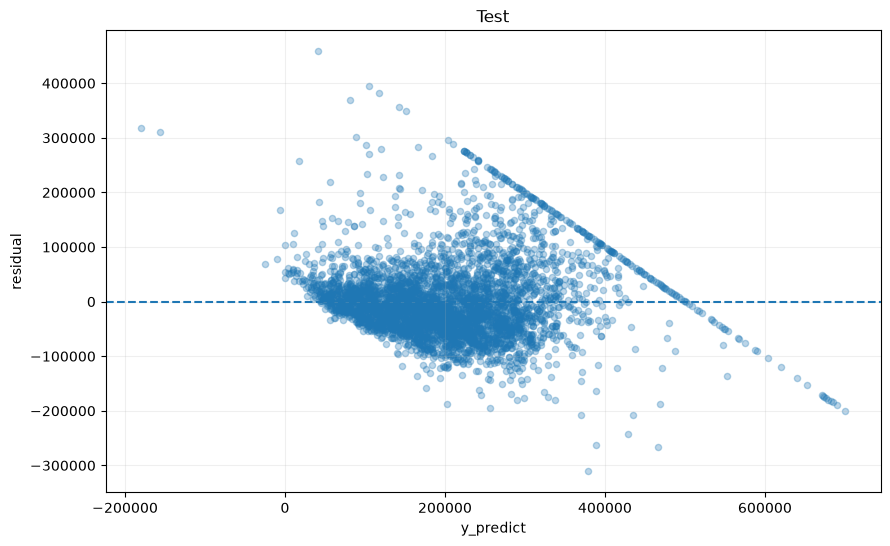

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_predict,
    residual,
    alpha=0.3,
    s=20
)

plt.axhline(y=0, linestyle="--")

plt.title("Test")
plt.xlabel("y_predict")
plt.ylabel("residual")


plt.grid(True ,alpha=0.2)

plt.show()

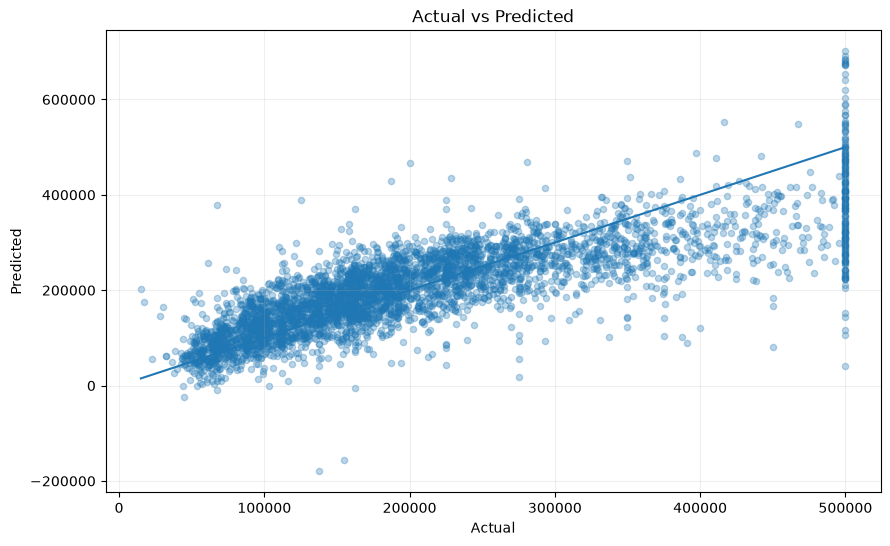

In [197]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_predict,
    alpha=0.3,
    s=20
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.grid(True, alpha=0.2)
plt.show()

Linear Regression baseline:
MAE ≈ 50.7k
RMSE ≈ 70.1k
R² ≈ 0.625

Residuals show non-random structure and possible heteroscedasticity.
Actual vs Predicted plot shows larger errors for high-value houses.
Target capping at 500001 affects the model behavior.